In [211]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [212]:
df = pd.read_csv('data.csv')
len(df)

11914

In [213]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [214]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [215]:
strings = list(df.dtypes[df.dtypes == 'str'].index)

In [216]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [217]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [218]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914
year
[2011 2012 2013 1992 1993]
28
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10
engine_hp
[335. 300. 230. 320. 172.]
356
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5
driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4
number_of_doors
[ 2.  4.  3. nan]
3
market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-performance

In [219]:
import seaborn as sns

<Axes: xlabel='msrp', ylabel='Count'>

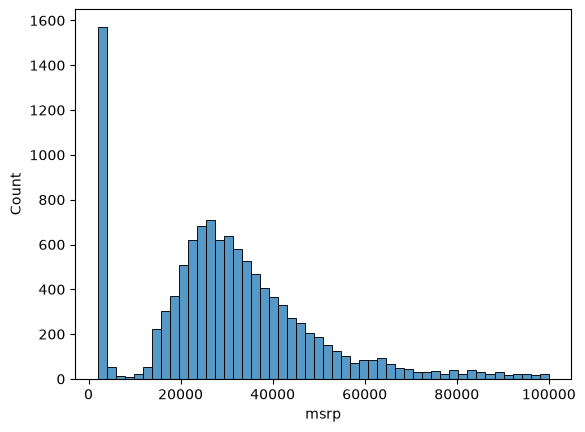

In [220]:
sns.histplot(df.msrp[df.msrp < 100000], bins = 50)

In [221]:
df_expensives = df[df['msrp'] > 1_000_000]

In [222]:
df_expensives.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
6350,maybach,landaulet,2011,premium_unleaded_(required),620.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,high-performance",large,convertible,16,10,67,1380000
6351,maybach,landaulet,2012,premium_unleaded_(required),620.0,12.0,automatic,rear_wheel_drive,4.0,"exotic,luxury,performance",large,convertible,16,10,67,1382750
8486,lamborghini,reventon,2008,premium_unleaded_(required),650.0,12.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,9,1158,1500000
11362,bugatti,veyron_16.4,2008,premium_unleaded_(required),1001.0,16.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,2065902
11363,bugatti,veyron_16.4,2008,premium_unleaded_(required),1001.0,16.0,automated_manual,all_wheel_drive,2.0,"exotic,high-performance",compact,coupe,14,8,820,1500000


In [223]:
np.log1p([0, 10, 100, 1000])

array([0.        , 2.39789527, 4.61512052, 6.90875478])

Vamos aplicar o log no conjunto de dados por causa da **cauda longa** que pode acabar confundindo o modelo: o log transforma razões (multiplicação) em diferenças (soma). Essa cauda longa, vista no gráfico, resulta em alguns valores muito grandes e muitos pequenos — o log puxa essa cauda para dentro e deixa a distribuição mais próxima de uma normal.

$$y' = \log(1 + y)$$

Para voltar à escala original (desfazer o log), aplicamos a inversa:

$$y = e^{y'} - 1$$

In [224]:
price_logs =  np.log10(df['msrp'])

<Axes: xlabel='msrp', ylabel='Count'>

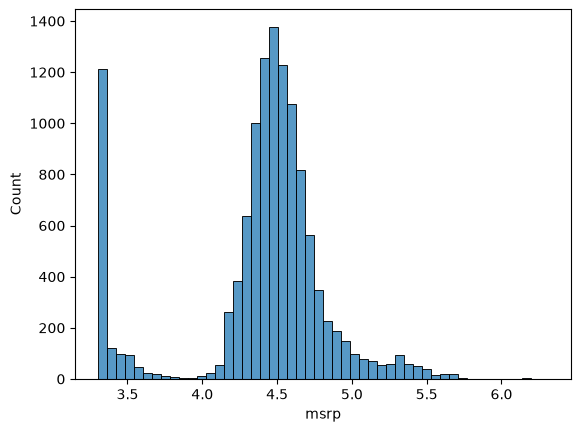

In [225]:
sns.histplot(price_logs, bins = 50)

In [226]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## Framework de validação

Dividimos o dataset em treino, validação e teste (60/20/20):

$$n_{val} = n_{test} = 0{,}2 \cdot n \qquad n_{train} = n - n_{val} - n_{test}$$

In [227]:
n = len(df)

n_val = int(len(df) * 0.2)
n_test = int(len(df) * 0.2)
n_train = n - n_val - n_test

n

11914

In [228]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [229]:
idx = np.arange(n)

In [230]:
np.random.seed(2)
np.random.shuffle(idx)

In [231]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [232]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [233]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [234]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)
# == Matriz de características X.

In [235]:
y_train = np.log1p(df_train.msrp.values)
y_test = np.log1p(df_test.msrp.values)
y_val = np.log1p(df_val.msrp.values)

In [236]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [237]:
len(y_train)

7150

## Regressão linear

$$g(x_i) \approx y_i$$

$g(x_i)$ é o carro, $y_i$ é o preço.

$$x_i = (x_{i1}, x_{i2}, \dots, x_{in})$$

Queremos uma função que receba todas essas características e produza um valor $\approx y_i$ (preço).

Exemplo: `df_train.iloc[10]` → $x_i$ (com $i = 10$) $= [453, 11, 86]$

In [238]:
xi = [453, 11, 86] #Deixando palpável com a explicação acima
def g(xi):
    #faça algo
    return 10000
g(xi)

10000

$$g(x_i) = w_0 + (w_1 \cdot x_{i1}) + (w_2 \cdot x_{i2}) + (w_3 \cdot x_{i3})$$

onde $w_0$ é o termo de viés (a previsão que faríamos sem saber nada sobre o carro), $w_1 \cdot x_{i1}$ é a capacidade do motor, $w_2 \cdot x_{i2}$ é o consumo na cidade multiplicado por um peso, e $w_3 \cdot x_{i3}$ é a popularidade.

Simplificando:

$$g(x_i) = w_0 + \sum_{j=1}^{n} w_j\, x_{ij} = \text{termo de viés} + \text{somatório de características} \times \text{peso}$$

Assumindo $x_{i0} = 1$:

$$g(x_i) = \sum_{j=0}^{n} w_j\, x_{ij}$$

que é o produto escalar entre o vetor de características e o vetor de pesos.

In [239]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [240]:
def linear_regression(xi): #Mensurando
    n = len(xi)
    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]
        
    return pred

In [241]:
linear_regression(xi) #Resultado da previsão

12.312

Provando o resultado com a fórmula:

$$g(x_i) = 7{,}17 + (453 \times 0{,}01) + (11 \times 0{,}04) + (86 \times 0{,}002) = 12{,}312$$

Cada característica afeta no preço do carro — por exemplo, quanto maior a força do motor, maior tende a ser o preço.

In [242]:
int(np.expm1(12.312))

222347

Como o log foi feito por causa da cauda longa dos dados, precisamos desfazê-lo — exponenciamos o resultado:

$$\text{preço} = e^{12{,}312} - 1 \approx 222347$$

Esse é o resultado do preço desse carro.

## Forma vetorial

Generalizando para a forma vetorial: transpomos o vetor de características $x_i$ e a soma vira um produto escalar.

$$g(x_i) = w_0 + x_i^{T} w$$

In [243]:
def dot(xi, w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j] * w[j]
    return res


$$w = [w_0,\, w_1,\, w_2,\, \dots,\, w_n] \qquad x_i = [x_{i0}=1,\, x_{i1},\, x_{i2},\, \dots,\, x_{in}]$$

$$w^{T} x_i = x_i^{T} w = w_0 + \dots$$

In [244]:
w_new = [w0] + w

In [245]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [246]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [247]:
linear_regression(xi)

12.312

In [248]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [249]:
x1 = [1, 148, 24, 1385] #carro 1
x2 = [1, 132, 25, 1031] #carro 2
x10 = [1, 453, 11, 86] #carro 3

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 1031],
       [   1,  453,   11,   86]])

In [250]:
X.dot(w_new) #Previsões, matriz * vetor

array([12.38 , 11.552, 12.312])

## Forma matricial

Generalizando para várias observações de uma vez, $X$ é a matriz de características (uma linha por carro) e a previsão para todos eles sai com uma única multiplicação matriz-vetor:

$$\hat{y} = Xw$$

In [251]:
def linear_regression(X):
    return X.dot(w_new)
#X.dot(w_new) #Previsões, matriz * veto

In [252]:
linear_regression(X)

array([12.38 , 11.552, 12.312])

## Treinando o modelo de regressão

(Como obtemos os pesos)

$$g(X) = Xw \approx y$$

(a matriz de características vezes o vetor de pesos tem que ser próximo de $y$)

## Como achar $w$

Sabemos que, se $X$ fosse uma matriz quadrada e invertível, bastaria multiplicar os dois lados de $Xw = y$ por $X^{-1}$:

$$X^{-1} X w = X^{-1} y$$

Sabemos que $X^{-1}X = I$, então:

$$w = X^{-1} y$$

Só que $X$ é uma matriz **retangular** — há muitas linhas e poucas colunas, definidas por $m \times (n+1)$ — e definitivamente a matriz não é quadrada, ou seja, a inversa não existe e não podemos "criar números"; temos que achar uma solução aproximada.

$$(X^{T} X)^{-1} X^{T} X\, w = (X^{T} X)^{-1} X^{T} y$$

Aqui deixamos a matriz do meio quadrada, e dessa forma podemos cortar a parte $(X^{T} X)^{-1} X^{T} X$ e substituir por $I$:

$$I w = w \quad\Rightarrow\quad w = (X^{T} X)^{-1} X^{T} y$$

In [253]:
X = [
    [148, 24, 1385],
    [132, 25, 2031], 
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201], 
    [413, 11, 86],
    [38, 54, 185],
    [142, 25, 431], 
    [453, 31, 86]
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [254]:
w0 = w_full[0]
w = w_full[1:]

w0, w

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [255]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = (np.column_stack([ones, X]))

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    XTX.dot(XTX_inv).round(1)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [256]:
train_linear_regression(X, y)

(np.float64(25844.754055766753),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [257]:
#Construindo o modelo base de predição de carros

In [258]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [259]:
base = ['engine_hp', 'engine_cylinders', 
        'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base].values

In [260]:
X_train = df_train[base].fillna(0) #Ignora a característica que ha valores ausentes

In [261]:
w0, w = train_linear_regression(X_train, y_train)

In [262]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

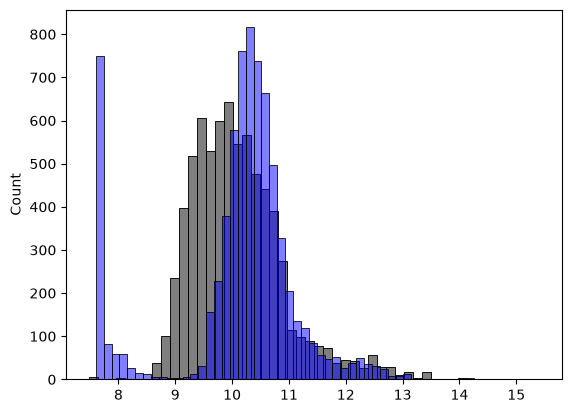

In [263]:
sns.histplot(y_pred, color = 'black', alpha = 0.5, bins = 50) #preto = previsões
sns.histplot(y_train, color = 'blue', alpha = 0.5, bins = 50) #Azul = variáveis alvo

In [264]:
#Avaliação do modelo de regressã(erro quadratico medio -> RMSE
#RMSE = √1/m * ∑(g(xi)(*previsao para xi) - yi(*valor real))ˆ2

#Decompondo:
#(g(xi) - yi)ˆ2 -> diferença entre a previsão e o valor real, o quadrado pune os erros maiores

#Isso apresentado acima é o erro quadrático, agora calculamos a média e a raiz de 1/m.

In [265]:
def rmse(y, y_pred):
    se = (y - y_pred) **2
    mse = se.mean()
    
    return np.sqrt(mse)

In [267]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

In [268]:
#Validando o modelo

In [ ]:
base = ['engine_hp', 'engine_cylinders', 
        'highway_mpg', 'city_mpg', 'popularity']

X_train = df_train[base].values

X_train = df_train[base].fillna(0)

w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_train.dot(w)

In [270]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [271]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.761653099130156)

In [272]:
#Adicionando mais recursos ao modelo

In [273]:
df_train.year.max()

np.int64(2017)

In [284]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df.year
    features = base + ['age']
    
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [285]:
X_train = prepare_X(df_train)

In [286]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5172055461058299)

<Axes: ylabel='Count'>

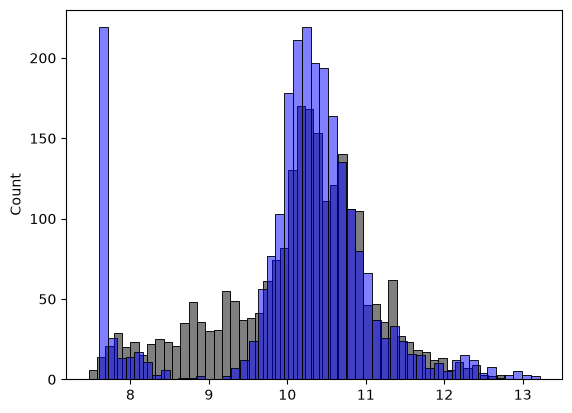

In [288]:
sns.histplot(y_pred, color = 'black', alpha = 0.5, bins = 50) #preto = previsões
sns.histplot(y_val, color = 'blue', alpha = 0.5, bins = 50) #Azul = variáveis alvo

In [289]:
#Variáveis categóricas